# 5. live demo: full pipeline on real images, explanations, federated learning and video

**what this notebook shows:** the working system. it loads the trained model, classifies real test images, makes decisions, explains one decision with a heat map, runs a small federated learning simulation and shows the video survey result.

In [1]:
# find the project folder, so the notebook works from any place
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root / "src"))
print("project folder:", root)

project folder: C:\Users\91738\edge-waste


In [2]:
# load the trained model and calibrate the thresholds on the validation set (never on the test set)
import numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from edgewaste import taxonomy as tx
from edgewaste.config import Config
from edgewaste.common_utils import pick_device
from edgewaste.classification.run_inference import load_for_inference
from edgewaste.decision_engine.conformal_routing import alpha_vector, calibrate, family_matrix, prediction_sets
from edgewaste.decision_engine.routing_rules import decide

cfg = Config.load("configs/classifier_convnext_vit.yaml")
cfg.model.pretrained = False
dev = pick_device()
model, names, tfm = load_for_inference("runs/stage1/best.pt", cfg, dev)
head = model.head
M = family_matrix(list(names))

val = np.load("runs/analysis/convnext_vit/cache_val.npz", allow_pickle=True)
test = np.load("runs/analysis/convnext_vit/cache_test.npz", allow_pickle=True)
probs_val = torch.softmax(torch.from_numpy(val["logits"].astype(np.float32)), 1).numpy().astype(np.float64)
q = calibrate(probs_val @ M, M[val["labels"].astype(int)].argmax(1), alpha_vector(0.10, 0.05))

@torch.no_grad()
def mc(emb, passes=25):
    head.train()
    p = torch.stack([torch.softmax(head(emb), 1) for _ in range(passes)]).mean(0)
    head.eval()
    return -(p * (p + 1e-12).log()).sum(1) / np.log(p.shape[1])

tau_u = float(np.quantile(mc(torch.from_numpy(val["emb"].astype(np.float32)).to(dev)).cpu().numpy(), 0.90))
print(f"device {dev} | uncertainty threshold {tau_u:.3f} | hazard family threshold {q[tx.FAMILY_TO_INDEX['hazardous']]:.3f}")

device cuda | uncertainty threshold 0.730 | hazard family threshold 0.770


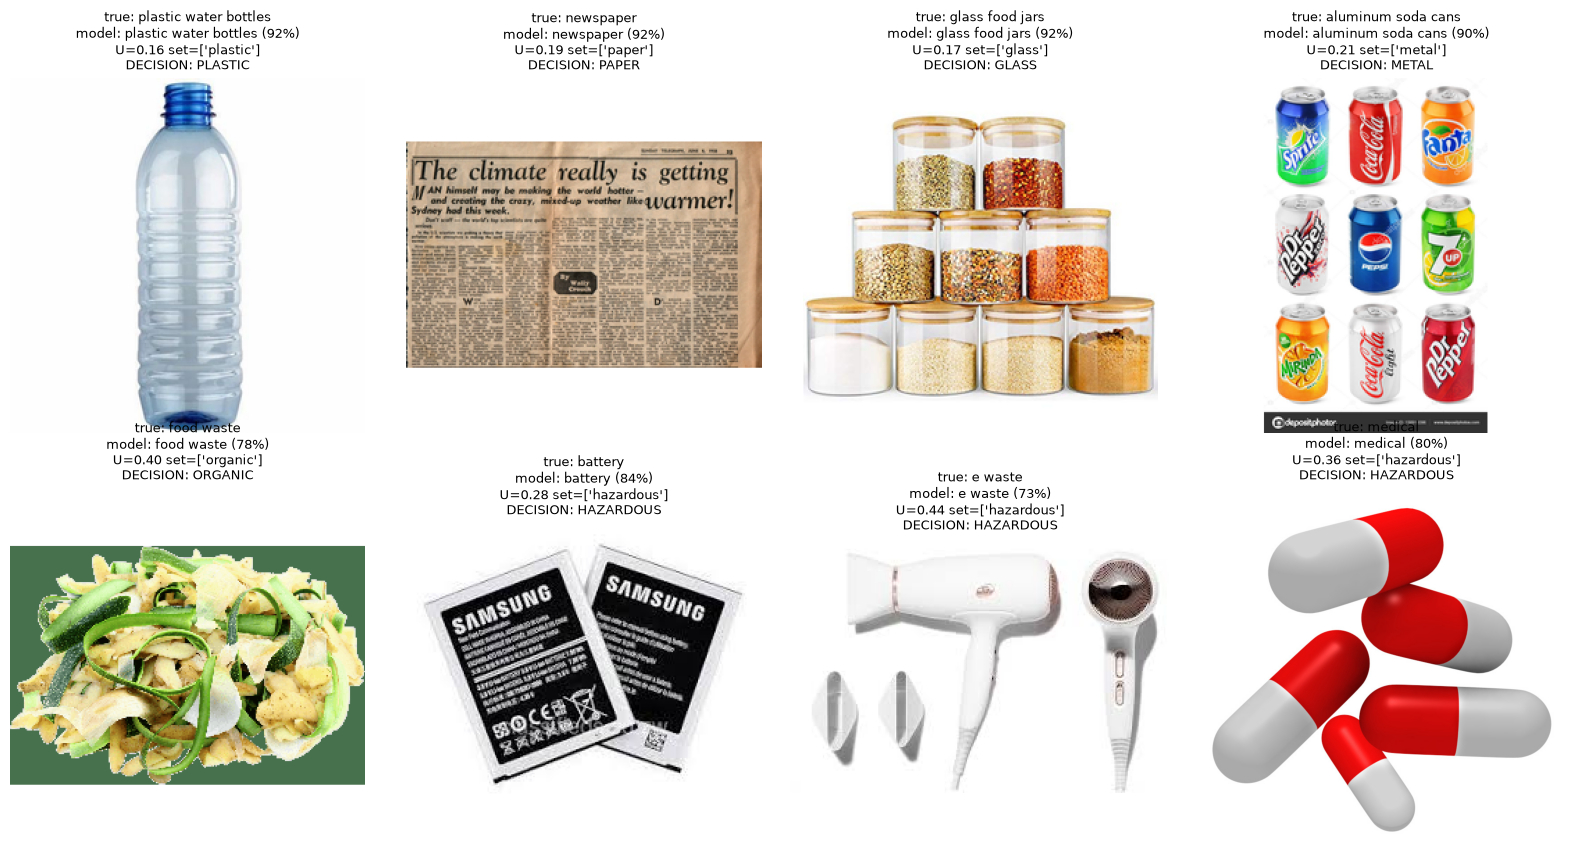

In [3]:
# the whole pipeline for one image: classify, measure uncertainty, build the family set, decide
@torch.no_grad()
def run_pipeline(img):
    x = tfm(img.convert("RGB")).unsqueeze(0).to(dev)
    model.eval()
    emb = model.feature_vector(x)
    p = torch.softmax(head(emb), 1)[0].cpu().numpy().astype(np.float64)
    u = float(mc(emb)[0])
    fam_set = {tx.FAMILIES[i] for i in np.where(prediction_sets((p @ M)[None, :], q)[0])[0]}
    top = int(p.argmax())
    return names[top], float(p[top]), u, fam_set, decide(names[top], p[top], u, None, uncertainty_threshold=tau_u, family_set=fam_set)

# pick 8 test images: a mix of normal items and hazards
rng = np.random.default_rng(3)
wanted = ["plastic_water_bottles", "newspaper", "glass_food_jars", "aluminum_soda_cans", "food_waste", "battery", "e_waste", "medical"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, cls in zip(axes.ravel(), wanted):
    idx = np.where(test["labels"] == names.index(cls))[0]
    path = test["paths"][int(rng.choice(idx))]
    img = Image.open(path).convert("RGB")
    name, conf, u, fam_set, d = run_pipeline(img)
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"true: {cls.replace('_', ' ')}\nmodel: {name.replace('_', ' ')} ({conf * 100:.0f}%)\nU={u:.2f} set={sorted(fam_set)}\nDECISION: {d.route.upper()}", fontsize=9)
plt.tight_layout(); plt.show()

## explain a decision with grad-cam

the heat map shows which parts of the picture pushed the model towards its answer (red = strong).

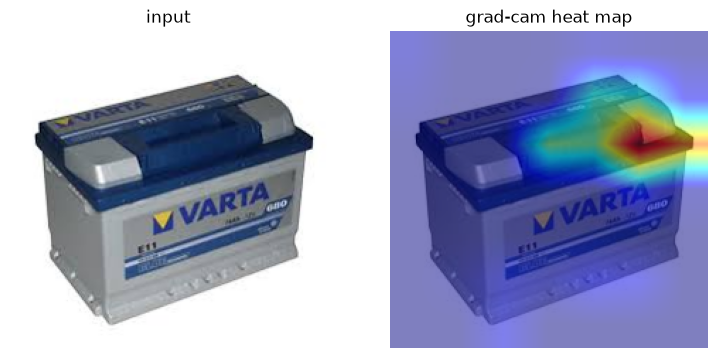

In [4]:
# grad-cam on one image (explains the convnext part of the model)
from edgewaste.explainability.gradcam_explanation import build_gradcam, gradcam_overlay
cam = build_gradcam(model)
path = test["paths"][int(rng.choice(np.where(test["labels"] == names.index("battery"))[0]))]
img = Image.open(path).convert("RGB")
rgb, overlay = gradcam_overlay(cam, model, tfm, img, dev, class_idx=names.index("battery"))
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(rgb); ax[0].set_title("input"); ax[1].imshow(overlay); ax[1].set_title("grad-cam heat map")
for a in ax:
    a.axis("off")
plt.show()

## federated learning (small simulation)

five sorting units each keep their own images and different class mixes. in every round they train a local copy and send **only parameters** to a server, which averages them: `new model = sum( (images of unit / all images) * parameters of unit )`. for speed this uses the saved image features and trains only the classifier layers.

In [5]:
# federated averaging on saved features: 5 units, uneven data, 8 rounds
import torch.nn as nn
train = np.load("runs/analysis/convnext_vit/cache_train.npz", allow_pickle=True)
Xtr = torch.from_numpy(train["emb"].astype(np.float32)); ytr = torch.from_numpy(train["labels"].astype(np.int64))
Xte = torch.from_numpy(test["emb"].astype(np.float32)); yte = torch.from_numpy(test["labels"].astype(np.int64))
K, ROUNDS, LOCAL_EPOCHS = 5, 8, 2
torch.manual_seed(0); rng = np.random.default_rng(0)

# give every unit a different mix of classes (dirichlet split)
parts = [[] for _ in range(K)]
for c in range(33):
    ids = np.where(ytr.numpy() == c)[0]
    share = rng.dirichlet([0.3] * K)
    cuts = (np.cumsum(share) * len(ids)).astype(int)[:-1]
    for k, chunk in enumerate(np.split(rng.permutation(ids), cuts)):
        parts[k] += chunk.tolist()
sizes = [len(p) for p in parts]
print("images per unit:", sizes)

def new_model():
    return nn.Sequential(nn.Linear(1024, 512), nn.GELU(), nn.Linear(512, 33))

def local_train(m, ids, epochs):
    opt = torch.optim.AdamW(m.parameters(), 1e-3, weight_decay=1e-2)
    ids = torch.tensor(ids)
    for _ in range(epochs):
        order = ids[torch.randperm(len(ids))]
        for b in range(0, len(order), 128):
            i = order[b:b + 128]
            opt.zero_grad(); nn.functional.cross_entropy(m(Xtr[i]), ytr[i]).backward(); opt.step()

def accuracy(m):
    return float((m(Xte).argmax(1) == yte).float().mean())

global_model, curve = new_model(), []
for r in range(ROUNDS):
    states = []
    for k in range(K):
        local = new_model(); local.load_state_dict(global_model.state_dict())
        local_train(local, parts[k], LOCAL_EPOCHS)
        states.append(local.state_dict())
    # weighted average of the parameters of all units
    avg = {key: sum(states[k][key] * (sizes[k] / sum(sizes)) for k in range(K)) for key in states[0]}
    global_model.load_state_dict(avg)
    curve.append(accuracy(global_model))
    print(f"round {r + 1}: shared model accuracy {curve[-1] * 100:.1f}%")

central = new_model(); local_train(central, list(range(len(ytr))), 8)
alone = []
for k in range(K):
    m = new_model(); local_train(m, parts[k], LOCAL_EPOCHS * ROUNDS); alone.append(accuracy(m))
print(f"\none central model: {accuracy(central) * 100:.1f}%  |  units training alone: {np.mean(alone) * 100:.1f}% on average")

images per unit: [6003, 3772, 4621, 2378, 2965]


round 1: shared model accuracy 85.8%


round 2: shared model accuracy 90.1%


round 3: shared model accuracy 89.7%


round 4: shared model accuracy 89.6%


round 5: shared model accuracy 90.0%


round 6: shared model accuracy 89.6%


round 7: shared model accuracy 89.7%


round 8: shared model accuracy 89.7%



one central model: 89.2%  |  units training alone: 81.5% on average


## video litter survey

a tracker gives every object an id, so one object seen in many frames is counted once. below is the saved result for a 240-frame test video made from 12 real litter photographs.

In [6]:
# the inventory made by the video pipeline
import pandas as pd
print(open("reports/demo/video/inventory.txt").read()[:1400])
tracks = pd.read_csv("reports/demo/video/tracks.csv")
print("inventory entries:", len(tracks), "| per-frame detections merged:", int(tracks["frames_visible"].sum()))
tracks[["track_id", "object_class", "material", "uncertainty", "route", "frames_visible"]].head(8)

LITTER INVENTORY REPORT
Source           : runs/_testvideo/survey_test.mp4
Generated        : 2026-10-01T11:49:45
Frames processed : 240
Unique items     : 16   (de-duplicated across frames by track ID)
Flagged contaminated (OCI >= 0.50): 0
Material corrected by identity prior: 5
Unresolved object/material contradictions: 4
Hazard-suspected but too uncertain to act on (priority review): 12

BY OBJECT TYPE
----------------------------------------------
  Cup                              6
  Plastic bag - wrapper            4
  Can                              2
  Carton                           2
  Bottle cap                       1
  Other litter                     1

BY MATERIAL
----------------------------------------------
  medical                         10
  cardboard_packaging              4
  e_waste                          2

BY ROUTING DECISION
----------------------------------------------
  manual_review                   16

OBJECT/MATERIAL CONTRADICTIONS (routed to man

,track_id,object_class,material,uncertainty,route,frames_visible
0,1,Cup,cardboard_packaging,0.457,manual_review,17
1,12,Plastic bag - wrapper,e_waste,0.568,manual_review,19
2,13,Cup,cardboard_packaging,0.378,manual_review,19
3,14,Can,medical,0.781,manual_review,19
4,15,Cup,cardboard_packaging,0.581,manual_review,19
5,16,Can,cardboard_packaging,0.529,manual_review,9
6,20,Bottle cap,medical,0.608,manual_review,20
7,40,Cup,medical,0.840,manual_review,1
